In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from textblob import TextBlob
from nltk.sentiment import SentimentIntensityAnalyzer
import nltk

nltk.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

In [ ]:
import pandas as pd

df = pd.read_csv(
    "IMDB Dataset.csv",
    engine="python",
    encoding="utf-8",
    on_bad_lines="skip"
)

df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [ ]:
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


In [ ]:
df.isnull().sum()

,0
review,0
sentiment,0


In [ ]:
df.duplicated().sum()


np.int64(418)

In [ ]:
df = df.drop_duplicates()

In [ ]:
df["sentiment"].value_counts()

,count
sentiment,
positive,24884
negative,24698


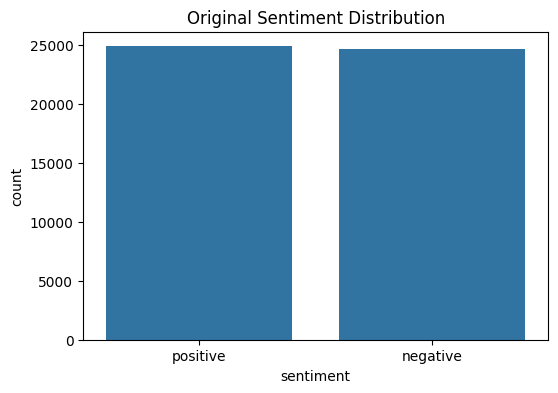

In [ ]:

plt.figure(figsize=(6,4))

sns.countplot(data=df,x="sentiment")

plt.title("Original Sentiment Distribution")

plt.show()

In [ ]:
def predict_sentiment(text):

    polarity = TextBlob(str(text)).sentiment.polarity

    if polarity > 0:
        return "positive"

    elif polarity < 0:
        return "negative"

    else:
        return "neutral"

In [ ]:
df["Predicted_Sentiment"] = df["review"].apply(predict_sentiment)

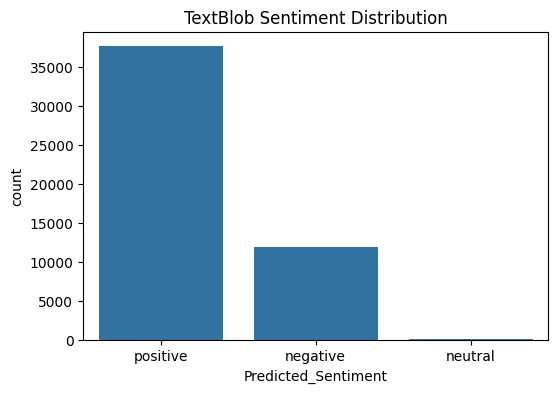

In [ ]:
plt.figure(figsize=(6,4))

sns.countplot(data=df,x="Predicted_Sentiment")

plt.title("TextBlob Sentiment Distribution")

plt.show()

In [ ]:
sia = SentimentIntensityAnalyzer()

In [ ]:
def vader_sentiment(text):

    score = sia.polarity_scores(str(text))["compound"]

    if score >= 0.05:
        return "positive"

    elif score <= -0.05:
        return "negative"

    else:
        return "neutral"

In [ ]:
df["VADER_Sentiment"] = df["review"].apply(vader_sentiment)

In [ ]:
df[["review","sentiment","Predicted_Sentiment","VADER_Sentiment"]].head()

In [ ]:
plt.figure(figsize=(6,4))

sns.countplot(data=df,x="VADER_Sentiment")

plt.title("VADER Sentiment Distribution")

plt.show()

In [ ]:
reviews = [

"This movie is amazing!",

"Worst movie ever.",

"It was okay.",

"Excellent acting.",

"Terrible story."

]

for review in reviews:

    print("Review:", review)

    print("TextBlob:", predict_sentiment(review))

    print("VADER:", vader_sentiment(review))

    print("-"*50)

Review: This movie is amazing!
TextBlob: positive
VADER: positive
--------------------------------------------------
Review: Worst movie ever.
TextBlob: negative
VADER: negative
--------------------------------------------------
Review: It was okay.
TextBlob: positive
VADER: positive
--------------------------------------------------
Review: Excellent acting.
TextBlob: positive
VADER: positive
--------------------------------------------------
Review: Terrible story.
TextBlob: negative
VADER: negative
--------------------------------------------------


## Observations

- The dataset contains movie reviews labeled as positive and negative.
- TextBlob and VADER were used for sentiment classification.
- Both methods identified positive, negative, and neutral sentiments.
- The sentiment distribution helps understand customer opinions and public trends.
- Businesses can use these insights to improve products, marketing strategies, and customer satisfaction.

## Conclusion

This project demonstrates sentiment analysis using Natural Language Processing (NLP).

TextBlob and VADER were applied to classify movie reviews into positive, negative, and neutral sentiments.

The results help understand public opinion and support business decisions such as product improvements, marketing campaigns, and customer experience enhancement.